In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [2]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 53)


In [3]:
df_map = df_map.copy()

df_map = df_map.drop_duplicates(subset=["id", "pesid"])

In [4]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# Limpeza da BR
# =============================

def limpar_br(df):
    return (
        df["br"]
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.replace("BR-", "", regex=False)
        .str.strip()
    )

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

df_filtrado = df_map.copy()

if br_escolhida.strip() != "":
    df_filtrado = df_filtrado[df_filtrado["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_filtrado.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()

# =============================
# Limpeza coordenadas
# =============================

cols = ["latitude", "longitude", "km"]

for col in cols:
    df_filtrado[col] = pd.to_numeric(
        df_filtrado[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

df_filtrado = df_filtrado.dropna(subset=["latitude", "longitude", "km"])

# =============================
# KM BIN
# =============================

df_filtrado["km_bin"] = ((df_filtrado["km"] // 5) * 5).astype(int)

# =============================
# Índice de severidade (AGORA FILTRADO)
# =============================

df_filtrado["severity_index"] = (
    4 * df_filtrado["Sum_Mortos"] +
    2 * df_filtrado["Sum_Feridos_Graves"] +
    1 * df_filtrado["Sum_Feridos_Leves"]
)

# =============================
# Agrupamento (AGORA FILTRADO)
# =============================

df_segmento = df_filtrado.groupby(["br", "uf", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()
# =============================
# Classificação de veículos
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]
carros_leves = ["Automóvel"]
caminhonetes = ["Caminhonete", "Camioneta", "Utilitário"]
motos = ["Motocicleta", "Motoneta"]
ciclomotores = ["Ciclomotor", "Triciclo", "Quadriciclo"]

# NOVO 🚍
onibus = ["Ônibus", "Micro-ônibus"]

# =============================
# Criar mapa
# =============================

m = folium.Map(
    location=[df_filtrado["latitude"].median(), df_filtrado["longitude"].median()],
    zoom_start=6
)

# =============================
# Camadas
# =============================

layer_todos = MarkerCluster(name="🔴 Todos acidentes com mortos").add_to(m)
layer_caminhao = MarkerCluster(name="🚛 Caminhões").add_to(m)
layer_carro = MarkerCluster(name="🚗 Automóveis").add_to(m)
layer_caminhonete = MarkerCluster(name="🚙 Caminhonetes").add_to(m)
layer_moto = MarkerCluster(name="🏍 Motocicletas").add_to(m)
layer_ciclomotor = MarkerCluster(name="🛵 Ciclomotores").add_to(m)

# NOVO 🚍
layer_onibus = MarkerCluster(name="🚌 Ônibus").add_to(m)

# =============================
# Agrupamento auxiliar
# =============================

segmentos_grupo = df_filtrado.groupby(["br", "uf", "km_bin"])

# =============================
# Plotagem
# =============================

for _, row in df_segmento.iterrows():

    try:
        grupo = segmentos_grupo.get_group(
            (row["br"], row["uf"], row["km_bin"])
        )
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Flags de veículos
    tem_caminhao = grupo["tipo_veiculo"].isin(caminhao).any()
    tem_carro = grupo["tipo_veiculo"].isin(carros_leves).any()
    tem_caminhonete = grupo["tipo_veiculo"].isin(caminhonetes).any()
    tem_moto = grupo["tipo_veiculo"].isin(motos).any()
    tem_ciclomotor = grupo["tipo_veiculo"].isin(ciclomotores).any()
    tem_onibus = grupo["tipo_veiculo"].isin(onibus).any()  # NOVO

    # Popup
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
    <b>BR:</b> {row['br']} - {row['uf']} | <b>KM:</b> {row['km_bin']}<br>
    <b>Total de acidentes:</b> {row['n_acidentes']}<br>
    <b>Total de mortos:</b> {row['total_mortos']}<br>
    <hr><b>Top Veículos:</b><br>{veiculo_txt}
    """

    radius = 7 + (np.log1p(row["total_mortos"]) * 3)

    # Geral
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layer_todos)

    # Camadas específicas
    if tem_caminhao:
        folium.CircleMarker([lat, lon], radius=radius, color="purple", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhao)

    if tem_carro:
        folium.CircleMarker([lat, lon], radius=radius, color="blue", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_carro)

    if tem_caminhonete:
        folium.CircleMarker([lat, lon], radius=radius, color="darkgreen", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhonete)

    if tem_moto:
        folium.CircleMarker([lat, lon], radius=radius, color="orange", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_moto)

    if tem_ciclomotor:
        folium.CircleMarker([lat, lon], radius=radius, color="black", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_ciclomotor)

    # NOVO 🚍
    if tem_onibus:
        folium.CircleMarker(
            [lat, lon],
            radius=radius,
            color="pink",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_onibus)

# =============================
# Controle
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# Salvar
# =============================

path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html"

m.save(path)

print(f"Mapa gerado com sucesso em: {path}")

<>:210: SyntaxWarning: invalid escape sequence '\E'
<>:210: SyntaxWarning: invalid escape sequence '\E'
C:\Users\fause\AppData\Local\Temp\ipykernel_23984\1520945810.py:210: SyntaxWarning: invalid escape sequence '\E'
  path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html"


Mostrando todas as rodovias
Mapa gerado com sucesso em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html


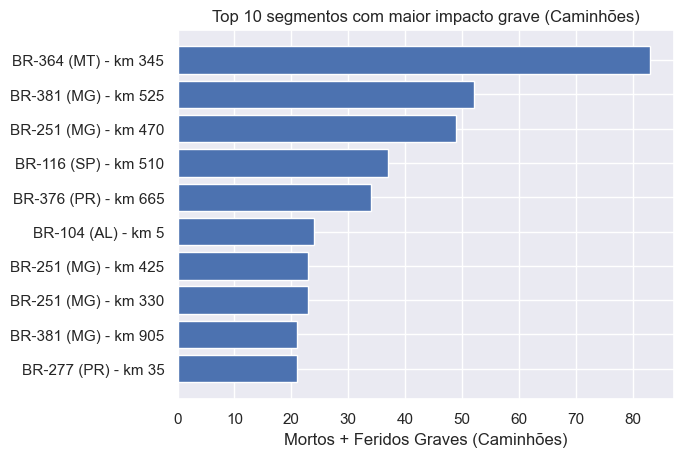

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos de caminhão
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]

# =============================
# 2️⃣ Filtrar base original (IMPORTANTE)
# =============================

df_caminhao = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(caminhao)
].copy()

# Segurança: remover linhas inválidas
df_caminhao = df_caminhao.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_caminhao["severity_index"] = (
    4 * df_caminhao["Sum_Mortos"] +
    2 * df_caminhao["Sum_Feridos_Graves"] +
    1 * df_caminhao["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_caminhao = df_caminhao.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_caminhao["segmento"] = (
    "BR-" + df_segmento_caminhao["br"].astype(str) + " (" +
    df_segmento_caminhao["uf"] + ") - km " +
    df_segmento_caminhao["km_bin"].astype(str)
)

# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_caminhao["impacto_grave"] = (
    df_segmento_caminhao["total_mortos"] +
    df_segmento_caminhao["total_feridos_graves"]
)

top10_impacto_caminhao = df_segmento_caminhao.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_caminhao["segmento"],
    top10_impacto_caminhao["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Caminhões)")
plt.title("Top 10 segmentos com maior impacto grave (Caminhões)")
plt.gca().invert_yaxis()

plt.show()



In [6]:
def consulta_por_variavel(df_original, df_top10, coluna_consulta):
    """
    df_original: df_caminhao (ou df_filtrado já tratado)
    df_top10: top10_impacto_caminhao
    coluna_consulta: string (ex: 'Fabricante', 'tipo_acidente')
    """

    # =============================
    # 1️⃣ Filtrar apenas segmentos do Top 10
    # =============================
    
    df_filtrado_top = df_original.merge(
        df_top10[["br", "uf", "km_bin"]],
        on=["br", "uf", "km_bin"],
        how="inner"
    )

    # =============================
    # 2️⃣ Agrupar dinamicamente
    # =============================
    
    resultado = df_filtrado_top.groupby(
        ["br", "uf", "km_bin", coluna_consulta]
    ).size().reset_index(name="quantidade")

    # =============================
    # 3️⃣ Criar nome do segmento
    # =============================
    
    resultado["segmento"] = (
        "BR-" + resultado["br"].astype(str) + " (" +
        resultado["uf"] + ") - km " +
        resultado["km_bin"].astype(str)
    )

    # =============================
    # 4️⃣ Ordenar resultados
    # =============================
    
    resultado = resultado.sort_values(
        ["segmento", "quantidade"],
        ascending=[True, False]
    )

    return resultado

In [7]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "Fabricante"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Fabricante", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
   Fabricante  quantidade
MERCEDES-BENZ          16
   VOLKSWAGEN           7
         FORD           4
       SCANIA           2
        VOLVO           2
Não Informado           1

===== BR-116 (SP) - km 510 =====
   Fabricante  quantidade
       SCANIA          69
        VOLVO          37
MERCEDES-BENZ          35
        IVECO          27
   VOLKSWAGEN          22
         FORD          20
          DAF           9
          MAN           2
Não Informado           2
          IMP           1
     SINOTRUK           1

===== BR-251 (MG) - km 330 =====
   Fabricante  quantidade
        VOLVO          18
       SCANIA          16
MERCEDES-BENZ          15
   VOLKSWAGEN           7
         FORD           2
          DAF           1
        IVECO           1
          MAN           1

===== BR-251 (MG) - km 425 =====
   Fabricante  quantidade
       SCANIA          12
MERCEDES-BENZ          11
        VOLVO           8
   VOLKSWAGEN           5
        

In [31]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "tipo_veiculo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_veiculo", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
   tipo_veiculo  quantidade
       Caminhão          24
Caminhão-trator           8

===== BR-116 (SP) - km 510 =====
   tipo_veiculo  quantidade
Caminhão-trator         163
       Caminhão          62

===== BR-251 (MG) - km 330 =====
   tipo_veiculo  quantidade
Caminhão-trator          38
       Caminhão          23

===== BR-251 (MG) - km 425 =====
   tipo_veiculo  quantidade
Caminhão-trator          30
       Caminhão           9

===== BR-251 (MG) - km 470 =====
   tipo_veiculo  quantidade
Caminhão-trator         105
       Caminhão          71

===== BR-277 (PR) - km 35 =====
   tipo_veiculo  quantidade
Caminhão-trator          94
       Caminhão          20

===== BR-364 (MT) - km 345 =====
   tipo_veiculo  quantidade
Caminhão-trator         157
       Caminhão          72

===== BR-376 (PR) - km 665 =====
   tipo_veiculo  quantidade
Caminhão-trator         130
       Caminhão          83

===== BR-381 (MG) - km 525 =====
   tipo_veiculo  quantida

In [13]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "causa_acidente"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["causa_acidente", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
                                                      causa_acidente  quantidade
                                             Velocidade Incompatível           9
                                Demais falhas mecânicas ou elétricas           5
                                                Problema com o freio           5
                                                   Condutor Dormindo           3
                                                   Declive acentuado           3
                                         Defeito Mecânico no Veículo           2
                                   Acumulo de água sobre o pavimento           1
                            Desrespeitar a preferência no cruzamento           1
                                         Falta de Atenção à Condução           1
Falta de elemento de contenção que evite a saída do leito carroçável           1
                                              Ultrapassagem Indevida         

In [14]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "tipo_acidente"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_acidente", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
            tipo_acidente  quantidade
              Capotamento          11
               Tombamento           8
Saída de leito carroçável           5
          Colisão frontal           2
      Colisão transversal           2
    Derramamento de carga           2
       Colisão com objeto           1
                 Incêndio           1

===== BR-116 (SP) - km 510 =====
                  tipo_acidente  quantidade
                     Tombamento          59
             Colisão com objeto          34
               Colisão traseira          32
      Saída de leito carroçável          29
          Derramamento de carga          23
    Colisão com objeto estático          12
  Colisão lateral mesmo sentido          11
                  Engavetamento           8
                    Capotamento           5
                       Incêndio           5
   Queda de ocupante de veículo           3
Colisão com objeto em movimento           2
                Coli

In [16]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "fase_dia"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["fase_dia", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
   fase_dia  quantidade
  Pleno dia          18
Plena Noite          11
  Amanhecer           3

===== BR-116 (SP) - km 510 =====
   fase_dia  quantidade
  Pleno dia         137
Plena Noite          67
  Anoitecer          12
  Amanhecer           9

===== BR-251 (MG) - km 330 =====
   fase_dia  quantidade
  Pleno dia          42
Plena Noite          16
  Anoitecer           2
  Amanhecer           1

===== BR-251 (MG) - km 425 =====
   fase_dia  quantidade
  Pleno dia          24
Plena Noite          11
  Amanhecer           4

===== BR-251 (MG) - km 470 =====
   fase_dia  quantidade
  Pleno dia         120
Plena Noite          40
  Amanhecer          11
  Anoitecer           5

===== BR-277 (PR) - km 35 =====
   fase_dia  quantidade
  Pleno dia          68
Plena Noite          34
  Anoitecer           7
  Amanhecer           5

===== BR-364 (MT) - km 345 =====
   fase_dia  quantidade
  Pleno dia         150
Plena Noite          56
  Amanhecer          

In [17]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "condicao_metereologica"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["condicao_metereologica", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
condicao_metereologica  quantidade
             Céu Claro          17
               Nublado           6
                 Chuva           4
        Garoa/Chuvisco           2
                   Sol           2
      Nevoeiro/Neblina           1

===== BR-116 (SP) - km 510 =====
condicao_metereologica  quantidade
             Céu Claro         100
               Nublado          42
        Garoa/Chuvisco          38
                 Chuva          36
                   Sol           5
      Nevoeiro/Neblina           4

===== BR-251 (MG) - km 330 =====
condicao_metereologica  quantidade
             Céu Claro          40
               Nublado           8
                   Sol           7
                 Chuva           4
        Garoa/Chuvisco           1
              Ignorado           1

===== BR-251 (MG) - km 425 =====
condicao_metereologica  quantidade
             Céu Claro          23
                   Sol           6
                 Chuva    

In [18]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "tipo_pista"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_pista", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
tipo_pista  quantidade
   Simples          32

===== BR-116 (SP) - km 510 =====
tipo_pista  quantidade
   Simples         119
     Dupla         101
  Múltipla           5

===== BR-251 (MG) - km 330 =====
tipo_pista  quantidade
   Simples          61

===== BR-251 (MG) - km 425 =====
tipo_pista  quantidade
   Simples          39

===== BR-251 (MG) - km 470 =====
tipo_pista  quantidade
   Simples         176

===== BR-277 (PR) - km 35 =====
tipo_pista  quantidade
     Dupla         108
  Múltipla           3
   Simples           3

===== BR-364 (MT) - km 345 =====
tipo_pista  quantidade
     Dupla         206
   Simples          23

===== BR-376 (PR) - km 665 =====
tipo_pista  quantidade
     Dupla         151
   Simples          39
  Múltipla          23

===== BR-381 (MG) - km 525 =====
tipo_pista  quantidade
     Dupla         167

===== BR-381 (MG) - km 905 =====
tipo_pista  quantidade
     Dupla         112
  Múltipla           4


In [19]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "ano_fabricacao_veiculo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["ano_fabricacao_veiculo", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
 ano_fabricacao_veiculo  quantidade
                 2007.0           4
                 2011.0           4
                 1998.0           3
                 2003.0           2
                 2004.0           2
                 2013.0           2
                 2014.0           2
                    0.0           1
                 1981.0           1
                 1991.0           1
                 1993.0           1
                 1999.0           1
                 2000.0           1
                 2002.0           1
                 2005.0           1
                 2008.0           1
                 2010.0           1
                 2017.0           1
                 2019.0           1
                 2021.0           1

===== BR-116 (SP) - km 510 =====
 ano_fabricacao_veiculo  quantidade
                 2011.0          20
                 2018.0          19
                 2019.0          18
                 2020.0          1

In [21]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "Modelo_Grupo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Modelo_Grupo", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
                     Modelo_Grupo  quantidade
                           L 1620           3
                    L 1620/L 1620           3
                    19.320 CLC TT           2
                       13.180 CNM           1
                23.250 E/23.250 E           1
                   24.250 CNC 6X2           1
                   24.260 CRM 6X2           1
    24.280 CRM 6X2/24.280 CRM 6X2           1
                          710/710           1
                              712           1
            ATEGO 1419/ATEGO 1419           1
                       ATEGO 2426           1
            ATRON 1319/ATRON 1319           1
          AXOR 2035 S/AXOR 2035 S           1
    CARGO 2428 CNL/CARGO 2428 CNL           1
        CARGO 2428 E/CARGO 2428 E           1
                       CARGO 2429           1
        CARGO 2429 L/CARGO 2429 L           1
                    FH12 380 4X2T           1
                         L 1418 R           1
  

In [22]:
res_fabricante = consulta_por_variavel(
    df_caminhao,
    top10_impacto_caminhao,
    "Modelo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Modelo", "quantidade"]].to_string(index=False))


===== BR-104 (AL) - km 5 =====
Modelo  quantidade
     L           8
 CARGO           4
 19320           2
 ATEGO           2
    LS           2
 13180           1
 23250           1
 24250           1
 24260           1
 24280           1
   710           1
   712           1
 ATRON           1
  AXOR           1
  FH12           1
    NO           1
  T113           1
  T124           1
    VM           1

===== BR-116 (SP) - km 510 =====
     Modelo  quantidade
         FH          30
      CARGO          20
    STRALIS          19
          G          16
          R          14
       AXOR          13
       R124           9
      ATEGO           8
          P           7
       R450           7
      XF105           5
      24250           4
          L           4
     TECTOR           4
         VM           4
         XF           4
      19320           3
      19360           3
     ACTROS           3
       G410           3
         LS           3
      11180           2
  

In [23]:
def consulta_multiplas_variaveis(df_original, df_top10, colunas):
    """
    colunas: lista de colunas
    ex: ['Fabricante', 'Modelo_Grupo', 'Modelo', 'ano_fabricacao_veiculo']
    """

    # =============================
    # 1️⃣ Filtrar Top 10
    # =============================
    
    df_filtrado_top = df_original.merge(
        df_top10[["br", "uf", "km_bin"]],
        on=["br", "uf", "km_bin"],
        how="inner"
    )

    # =============================
    # 2️⃣ Agrupar por múltiplas colunas
    # =============================
    
    resultado = df_filtrado_top.groupby(
        ["br", "uf", "km_bin"] + colunas
    ).size().reset_index(name="quantidade")

    # =============================
    # 3️⃣ Criar segmento
    # =============================
    
    resultado["segmento"] = (
        "BR-" + resultado["br"].astype(str) + " (" +
        resultado["uf"] + ") - km " +
        resultado["km_bin"].astype(str)
    )

    # =============================
    # 4️⃣ Ordenar
    # =============================
    
    resultado = resultado.sort_values(
        ["segmento", "quantidade"],
        ascending=[True, False]
    )

    return resultado

In [ ]:
colunas = [
    "Fabricante",
    "Modelo_Grupo",
    "Modelo",
    "ano_fabricacao_veiculo"
]


res_veiculos = consulta_multiplas_variaveis(
    df_caminhao,
    top10_impacto_caminhao,
    colunas
)

In [30]:
for segmento, grupo in res_veiculos.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(
        grupo[colunas + ["quantidade"]]
        .head(10)  # top 5
        .to_string(index=False)
    )


===== BR-104 (AL) - km 5 =====
   Fabricante                  Modelo_Grupo  ano_fabricacao_veiculo  quantidade
         FORD CARGO 2428 CNL/CARGO 2428 CNL                  2011.0           1
         FORD     CARGO 2428 E/CARGO 2428 E                  2011.0           1
         FORD                    CARGO 2429                  2014.0           1
         FORD     CARGO 2429 L/CARGO 2429 L                  2013.0           1
MERCEDES-BENZ                       710/710                  2004.0           1
MERCEDES-BENZ                           712                  1993.0           1
MERCEDES-BENZ         ATEGO 1419/ATEGO 1419                  2019.0           1
MERCEDES-BENZ                    ATEGO 2426                  2017.0           1
MERCEDES-BENZ         ATRON 1319/ATRON 1319                  2013.0           1
MERCEDES-BENZ       AXOR 2035 S/AXOR 2035 S                  2007.0           1

===== BR-116 (SP) - km 510 =====
   Fabricante                    Modelo_Grupo  ano_fab